# Training DQN on Atari Breakout, step by step

This notebook opens up what `rlgames-sb train dqn --env ALE/Breakout-v5` does:

1. **The environment**: what the agent sees and which actions it can take
2. **One training example**: a single transition `(s, a, r, s', done)`
3. **A random baseline**: the score to beat
4. **The agent**: DQN's Q-network
5. **One DQN update, by hand**: replay buffer → TD target → loss → gradient step
6. **The full training loop**: `model.learn()`
7. **Evaluation**: trained agent vs random
8. **Saving**, so the CLI can continue training

It uses the same `envs` and `registry` modules as the CLI, so everything here
matches what the command line does.

In [1]:
import os
import time
from pathlib import Path

# Run from the repo root so saves land in ./saves, like the CLI.
if Path.cwd().name == "notebooks":
    os.chdir("..")

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from stable_baselines3.common.evaluation import evaluate_policy

from rl_games_sb import envs, registry

ENV_ID = "ALE/Breakout-v5"

## 1. The environment

`envs.make()` builds the env with the standard Atari preprocessing, plus
`FireOnNewLife` because Breakout waits for FIRE to launch the ball.

In [2]:
env = envs.make(ENV_ID)

print("Observation space:", env.observation_space)
print("Action space     :", env.action_space)
print("Actions          :", env.unwrapped.get_action_meanings())

# The wrapper stack, outermost first
w = env
while isinstance(w, gym.Wrapper):
    print("  ", type(w).__name__)
    w = w.env
print("  ", type(w).__name__)

Observation space: Box(0, 255, (4, 84, 84), uint8)
Action space     : Discrete(4)
Actions          : ['NOOP', 'FIRE', 'RIGHT', 'LEFT']
   Monitor
   FrameStackObservation
   FireOnNewLife
   AtariPreprocessing
   OrderEnforcing
   PassiveEnvChecker
   AtariEnv


### Raw frame vs. what the agent sees

The emulator produces 210×160 RGB frames. The preprocessing turns these into:

- **grayscale, 84×84**: color carries no information in Breakout and smaller inputs train faster
- **frame skip 4**: the agent picks an action every 4 frames, and that action is repeated
- **a stack of the last 4 frames**: one frame shows where the ball is, but not
  where it is going. Four frames show its velocity.

So one observation is a `uint8` array of shape `(4, 84, 84)`.

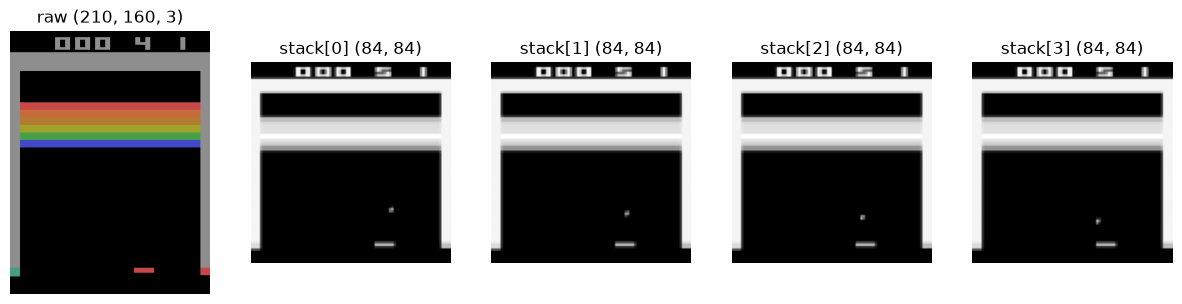

In [3]:
raw_env = gym.make(ENV_ID, render_mode="rgb_array")
raw_env.reset(seed=0)
for i in range(60):  # FIRE, then wait a bit so the ball is in play
    raw_env.step(1 if i == 0 else 0)
raw_frame = raw_env.render()
raw_env.close()

obs, _ = env.reset(seed=0)
for _ in range(10):
    obs, *_ = env.step(0)

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
axes[0].imshow(raw_frame)
axes[0].set_title(f"raw {raw_frame.shape}")
for i in range(4):
    axes[i + 1].imshow(obs[i], cmap="gray")
    axes[i + 1].set_title(f"stack[{i}] {obs[i].shape}")
for ax in axes:
    ax.axis("off")
plt.show()

## 2. One training example

Each step of the environment produces one **transition**:

| | |
|---|---|
| `s` | the observation before acting |
| `a` | the action taken |
| `r` | the reward received (+1, +4 or +7 per brick, depending on its row) |
| `s'` | the observation after acting |
| `done` | whether the game ended (all 5 lives lost) |

That tuple is the unit DQN learns from. The agent stores every transition in
a **replay buffer** and trains on random batches drawn from it.

s     : (4, 84, 84) uint8
a     : 1 (FIRE)
r     : 0.0
s'    : (4, 84, 84) uint8
done  : False  (truncated: False)
info  : {'lives': 5, 'episode_frame_number': 30, 'frame_number': 30}


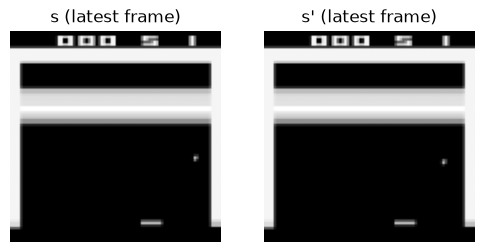

In [4]:
s, _ = env.reset(seed=0)
a = env.action_space.sample()
s_next, r, terminated, truncated, info = env.step(a)

print(f"s     : {s.shape} {s.dtype}")
print(f"a     : {a} ({env.unwrapped.get_action_meanings()[a]})")
print(f"r     : {r}")
print(f"s'    : {s_next.shape} {s_next.dtype}")
print(f"done  : {terminated}  (truncated: {truncated})")
print(f"info  : {info}")

fig, axes = plt.subplots(1, 2, figsize=(6, 3.5))
axes[0].imshow(s[-1], cmap="gray")
axes[0].set_title("s (latest frame)")
axes[1].imshow(s_next[-1], cmap="gray")
axes[1].set_title("s' (latest frame)")
for ax in axes:
    ax.axis("off")
plt.show()

## 3. Random baseline

A random policy sets the score to beat: how much does Breakout reward
pressing random buttons?

In [5]:
def play_random(n_episodes: int) -> list[float]:
    rewards = []
    for ep in range(n_episodes):
        env.reset(seed=ep)
        done, total = False, 0.0
        while not done:
            _, r, terminated, truncated, _ = env.step(env.action_space.sample())
            total += r
            done = terminated or truncated
        rewards.append(total)
    return rewards

random_rewards = play_random(10)
print(f"Random policy: {np.mean(random_rewards):.2f} +/- {np.std(random_rewards):.2f}")

Random policy: 2.10 +/- 1.22


## 4. The agent: DQN

DQN learns a **Q-function** `Q(s, a)`: the expected total future reward of
taking action `a` in state `s`, then playing well afterwards. To act, it picks
the action with the highest Q-value.

`registry.create()` sees an image observation and picks `CnnPolicy`: the
Nature-DQN convolutional network (3 conv layers → 512 units → one output per
action). It also caps the replay buffer at 50k transitions to fit in RAM.

In [6]:
model = registry.create("dqn", ENV_ID)
model.verbose = 0  # the notebook prints its own summaries

print(model.q_net)
print(f"\nParameters: {sum(p.numel() for p in model.q_net.parameters()):,}")
print(f"Device    : {model.device}")

Using cuda device
Wrapping the env in a DummyVecEnv.


QNetwork(
  (features_extractor): NatureCNN(
    (cnn): Sequential(
      (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
      (3): ReLU()
      (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      (5): ReLU()
      (6): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=3136, out_features=512, bias=True)
      (1): ReLU()
    )
  )
  (q_net): Sequential(
    (0): Linear(in_features=512, out_features=4, bias=True)
  )
)

Parameters: 1,686,180
Device    : cuda


The untrained network already outputs Q-values, but they are meaningless:

In [7]:
obs_tensor, _ = model.policy.obs_to_tensor(s)
with torch.no_grad():
    q_values = model.q_net(obs_tensor)[0].cpu().numpy()

for name, q in zip(env.unwrapped.get_action_meanings(), q_values):
    print(f"  Q(s, {name:<5}) = {q:+.4f}")
print(f"Greedy action: {env.unwrapped.get_action_meanings()[q_values.argmax()]}")

  Q(s, NOOP ) = +0.0374
  Q(s, FIRE ) = -0.0081
  Q(s, RIGHT) = -0.0029
  Q(s, LEFT ) = +0.0420
Greedy action: LEFT


## 5. One DQN update, by hand

Here is how a batch of training examples turns into a weight update.

For each transition `(s, a, r, s', done)` in the batch, DQN builds a **target**
from the reward it got plus its own estimate of what comes next:

$$
y = r + \gamma \,(1 - \text{done})\, \max_{a'} Q_{\text{target}}(s', a')
$$

and moves `Q(s, a)` towards `y` by minimizing the Huber (smooth L1) loss.

`Q_target` is a lagged copy of the Q-network, synced every 10k steps.
Without it the target would shift with every update and training would be
unstable.

First, collect some experience so the replay buffer has something to sample:

In [8]:
model.learn(total_timesteps=2_000)
print(f"Replay buffer: {model.replay_buffer.size():,} transitions")

Replay buffer: 2,000 transitions


In [9]:
batch = model.replay_buffer.sample(32)
rewards = batch.rewards.flatten()
dones = batch.dones.flatten()

# The TD target. No gradient flows through it.
with torch.no_grad():
    next_q = model.q_net_target(batch.next_observations).max(dim=1).values
    target = rewards + (1 - dones) * model.gamma * next_q

# The prediction: Q-value of the action actually taken
q_pred = model.q_net(batch.observations).gather(1, batch.actions.long()).flatten()

loss = F.smooth_l1_loss(q_pred, target)

print(" i | action | reward | done | max Q_target(s') | target y | Q(s, a)")
for i in range(8):
    print(
        f"{i:>2} | {batch.actions[i].item():>6} | {rewards[i]:>6.1f} | {dones[i]:>4.0f} "
        f"| {next_q[i]:>16.4f} | {target[i]:>8.4f} | {q_pred[i]:>7.4f}"
    )
print(f"\nLoss on this batch: {loss.item():.6f}")

 i | action | reward | done | max Q_target(s') | target y | Q(s, a)
 0 |      0 |    0.0 |    0 |           0.0423 |   0.0419 |  0.0491
 1 |      1 |    0.0 |    0 |           0.0424 |   0.0420 |  0.0517
 2 |      1 |    0.0 |    0 |           0.0419 |   0.0415 |  0.0407
 3 |      1 |    0.0 |    0 |           0.0414 |   0.0410 |  0.0438
 4 |      2 |    0.0 |    0 |           0.0420 |   0.0415 |  0.0404
 5 |      1 |    0.0 |    0 |           0.0416 |   0.0412 |  0.0453
 6 |      1 |    0.0 |    0 |           0.0416 |   0.0411 |  0.0454
 7 |      3 |    0.0 |    0 |           0.0424 |   0.0420 |  0.0404

Loss on this batch: 0.015318


Now take one gradient step, as `DQN.train()` does: backprop, clip gradients,
optimizer step. The loss on the same batch should go down:

In [10]:
optimizer = model.policy.optimizer
optimizer.zero_grad()
loss.backward()
torch.nn.utils.clip_grad_norm_(model.policy.parameters(), model.max_grad_norm)
optimizer.step()

with torch.no_grad():
    q_after = model.q_net(batch.observations).gather(1, batch.actions.long()).flatten()
    loss_after = F.smooth_l1_loss(q_after, target)

print(f"Loss before: {loss.item():.6f}")
print(f"Loss after : {loss_after.item():.6f}")

Loss before: 0.015318
Loss after : 0.015350


That is all of DQN's learning. Training repeats it thousands of times on
fresh random batches.

## 6. The full training loop

`model.learn()` runs this loop:

1. **Act**, epsilon-greedy: a random action with probability ε (decaying
   from 1.0 to 0.05 over the first 10% of training), otherwise the greedy one
2. **Store** the transition in the replay buffer
3. Every 4 steps, **sample** a batch of 32 and do the update from section 5
4. Every 10,000 steps, **copy** the Q-network into the target network

`TIMESTEPS` is kept small so this runs in a few minutes on a CPU. That shows
the mechanics, not a strong player: Breakout needs millions of timesteps
(about 10M for a good score).

In [11]:
TIMESTEPS = 50_000

start = time.time()
model.learn(total_timesteps=TIMESTEPS, reset_num_timesteps=False)
elapsed = time.time() - start
print(f"Trained {TIMESTEPS:,} steps in {elapsed:.0f}s ({TIMESTEPS / elapsed:.0f} steps/s)")
print(f"Total timesteps so far: {model.num_timesteps:,}")

Trained 50,000 steps in 76s (660 steps/s)
Total timesteps so far: 52,000


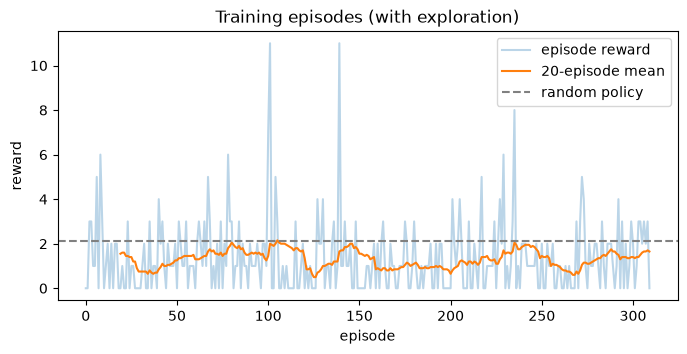

In [12]:
# The Monitor wrapper recorded every training episode's reward
episode_rewards = model.get_env().envs[0].get_episode_rewards()

window = 20
plt.figure(figsize=(8, 3.5))
plt.plot(episode_rewards, alpha=0.3, label="episode reward")
if len(episode_rewards) >= window:
    rolling = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")
    plt.plot(range(window - 1, len(episode_rewards)), rolling, label=f"{window}-episode mean")
plt.axhline(np.mean(random_rewards), color="gray", linestyle="--", label="random policy")
plt.xlabel("episode")
plt.ylabel("reward")
plt.title("Training episodes (with exploration)")
plt.legend()
plt.show()

## 7. Evaluation

The agent now plays greedily (no exploration). This is what
`rlgames-sb load dqn --env ALE/Breakout-v5 --eval` reports.

Don't expect the agent to beat random yet. After 50k steps the greedy
policy is still unreliable: it may score above or below random from one
run to the next. DQN usually needs around 1M steps before it clearly beats
random on Breakout, and about 10M to play well. Raise `TIMESTEPS` above,
or continue from the CLI (section 8), to watch that happen.

In [13]:
mean, std = evaluate_policy(model, envs.make(ENV_ID), n_eval_episodes=10)
print(f"Random policy : {np.mean(random_rewards):.2f} +/- {np.std(random_rewards):.2f}")
print(f"Trained agent : {mean:.2f} +/- {std:.2f}")

Random policy : 2.10 +/- 1.22
Trained agent : 0.00 +/- 0.00


### What the trained agent sees and does

A few frames from one greedy episode, with the Q-values behind each choice:

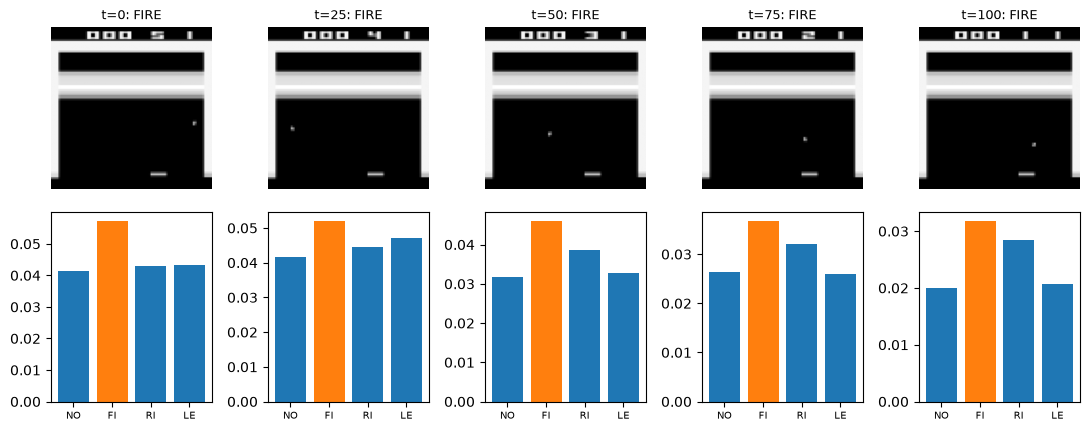

In [14]:
obs, _ = env.reset(seed=123)
meanings = env.unwrapped.get_action_meanings()
snapshots = []
for t in range(200):
    action, _ = model.predict(obs, deterministic=True)
    if t % 25 == 0:
        with torch.no_grad():
            q = model.q_net(model.policy.obs_to_tensor(obs)[0])[0].cpu().numpy()
        snapshots.append((t, obs[-1], q, int(action)))
    obs, _, terminated, truncated, _ = env.step(action)
    if terminated or truncated:
        break

fig, axes = plt.subplots(2, len(snapshots), figsize=(2.2 * len(snapshots), 4.5))
for col, (t, frame, q, action) in enumerate(snapshots):
    axes[0, col].imshow(frame, cmap="gray")
    axes[0, col].set_title(f"t={t}: {meanings[action]}", fontsize=9)
    axes[0, col].axis("off")
    axes[1, col].bar(range(len(q)), q, color=["C1" if i == action else "C0" for i in range(len(q))])
    axes[1, col].set_xticks(range(len(q)), [m[:2] for m in meanings], fontsize=7)
plt.tight_layout()
plt.show()

## 8. Save, and continue from the CLI

The model is saved where the CLI looks for it, so training can continue from
the terminal (`registry.load_or_create` resumes from the save):

```bash
rlgames-sb train  dqn --env ALE/Breakout-v5 --timesteps 2000000
rlgames-sb render dqn --env ALE/Breakout-v5
```

In [15]:
path = registry.save_path("dqn", ENV_ID)
model.save(path)
env.close()
print(f"Saved to {path}")

Saved to saves\dqn_ALE_Breakout-v5.zip
